In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
pip install pyspeckit

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 55.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.3/73.3 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 398.0/398.0 kB 19.7 MB/s eta 0:00:00
  Created wheel for pyspeckit: filename=pyspeckit-1.0.4-py3-none-any.whl size=2260971 sha256=b06328be72d16e2ab8a66b16efc5c3d4856d1fd470c854ea2e7c04da399a7c62
  Stored in directory: /root/.cache/pip/wheels/81/8a/ae/547b8c271ed88d8a38d1c0c7848f50df21294f599edd165c93
Successfully built pyspeckit


In [ ]:
import pyspeckit
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from astropy.io import fits
from tqdm import tqdm

In [ ]:
c = 3*10**(5)

In [ ]:
hdul = fits.open('cubo_ngc1365.fits')
data = hdul[1].data
wavelength = data['WAVELENGTH']
flux = data['OBJ']
fit = data['FIT']
emi = data['EMI']

In [ ]:



# Recortar rango 5800–6000 Å
mask = (wavelength >= 5800) & (wavelength <= 6000)
w_cut = wavelength[mask]
f_cut = flux[mask]
# Crear objeto Spectrum
spec = pyspeckit.Spectrum(xarr=w_cut, data=f_cut)

# Ajuste de baseline de orden 1 excluyendo ventanas en torno a las líneas
spec.baseline(exclude=[5865,5885, 5885,5895, 5895,5905], subtract=True, order=1)
# spec.plotter() #Plotea el espectro con el fiteo de las gaussianas

#Posiciones de las líneas
# HeI = 5876.0
NaI_1 = 5890.0
NaI_2 = 5896.0

# HeIb = 5876.0
NaI_1b = 5890.0
NaI_2b = 5896.0


# Estimar amplitudes iniciales
# amp_HeI = np.max(spec.data[(spec.xarr.value > HeI-3) & (spec.xarr.value < HeI+3)]) #Hacemos maximo poruqe emite
amp_NaI_1 = np.min(spec.data[(spec.xarr.value > NaI_1-10) & (spec.xarr.value < NaI_1+10)])#Hacemos minimo porque absorbe
amp_NaI_2 = np.min(spec.data[(spec.xarr.value > NaI_2-10) & (spec.xarr.value < NaI_2+10)])

# Guesses: [amplitud, longitud, sigma] por línea
guesses = [
    # amp_HeI, HeI, 3,
    # amp_HeI/2, HeIb, 5,

    amp_NaI_1, NaI_1, 3,
    amp_NaI_1/2, NaI_1b, 8,

    amp_NaI_2, NaI_2, 3,
    amp_NaI_2/2, NaI_2b, 8
]

#Tied Conditions:

tied = [
        # '', 'p[13] - 20', '', #HeI: (p 0-1-2)
        # '', '', '',           #HeI_extra : (p 3-4-5)

        '', 'p[7] - 6', '', #NaI_1: (p 6-7-8)
        '', '', '',  #NaI_1 extra: (p 9-10-11)

        '', '', 'p[2]',         #NaI_2: (p 12-13-14)
        '', 'p[4]+6', 'p[5]'           #NaI_2 extra: (p 15-16-17)

       ]
# Límites
parlimits = [
    # (0, amp_HeI), (HeI-3, HeI+3), (0, 3), #HeI
    # (0, amp_HeI), (HeIb-5, HeIb+5), (0, 5), #HeI extra

    (amp_NaI_1, 0), (NaI_1-10, NaI_1+10), (0, 5), #NaI_1
    (-np.inf, 0), (NaI_1b-10, NaI_1b+10), (0, 8), #NaI_1 extra

    (amp_NaI_2, 0), (NaI_2-10, NaI_2+10), (0, 5), #NaI_2
    (-np.inf, 0), (NaI_2b-10, NaI_2b+10), (0, 8) #NaI_2 extra
]

# Parámetros limitados o no
parlimited=[
            # (True,True),(True,True),(True, False), # HeI
			# (True,True),(False,False),(True,False),  # HeI extra

            (True,True),(True,True),(True,False), # NaI_1
	        (False,True),(False,False),(True,False), # NaI_1 extra

	        (True,True),(True,True),(True,False), # NaI_2
	        (False,True),(False,False),(True,False) # NaI_2 extra
           ]

# Ajuste de gaussianas
spec.specfit(guesses=guesses, fittype='gaussian', tied=tied,
             parlimits=parlimits, parlimited=parlimited, quiet=True)


wavelength_na = spec.xarr.value
flux_na = spec.data
model_na = spec.specfit.model  # modelo total ajustado


# Obtener componentes gaussianas ajustadas (cada 3 parámetros: amp, longitud, sigma)
params = spec.specfit.parinfo.values
n_lines = len(params)//3
# print(params)

# Función gaussiana
def gaussian(x, amp, cen, sigma):
    return amp * np.exp(-0.5 * ((x - cen) / sigma)**2)


# Calcular componentes
components = [] #Sirve para generar el plot
for i in range(n_lines):
    amp = params[3*i]
    cen = params[3*i + 1]
    sigma = params[3*i + 2]
    comp = gaussian(wavelength_na, amp, cen, sigma)
    components.append(comp)

# res = flux - model
# residuo = []
# wave_res = []
# n = len(wavelength)
# i = 0
# while i < n:
#     if (wavelength[i] >= 5880 and wavelength[i] <= 5905):
#         residuo.append(res[i])
#         wave_res.append(wavelength[i])
#     i = i+1



INFO:astropy:Left region selection unchanged.  xminpix, xmaxpix: 0,176


INFO: Left region selection unchanged.  xminpix, xmaxpix: 0,176 [pyspeckit.spectrum.interactive]


In [ ]:
#Lineas de magnesio

# Recortar rango 5100–5300 Å
mask_mg = (wavelength >= 5100) & (wavelength <= 5300)
w_cut_mg = wavelength[mask_mg]
f_cut_mg = flux[mask_mg]
fit_cut_mg = fit[mask_mg]
emi_cut_mg = emi[mask_mg]

# Crear objeto Spectrum
spec_mg = pyspeckit.Spectrum(xarr=w_cut_mg, data=fit_cut_mg)

# Ajuste de baseline de orden 1 excluyendo ventanas en torno a las líneas
spec_mg.baseline(exclude=[5140,5160, 5160,5180, 5180,5200], subtract=True, order=1)
# spec.plotter() #Plotea el espectro con el fiteo de las gaussianas

#Posiciones de las líneas
MgI_1 = 5167.0
MgI_2 = 5173.0
MgI_3 = 5184.0

# Estimar amplitudes iniciales

#MgI_1
amp_MgI_1 = np.min(spec_mg.data[(spec_mg.xarr.value > MgI_1 - 5) & (spec_mg.xarr.value < MgI_1 + 5)])

#MgI_2
amp_MgI_2 = np.min(spec_mg.data[(spec_mg.xarr.value > MgI_2 - 5) & (spec_mg.xarr.value < MgI_2 + 5)])

#MgI_1
amp_MgI_3 = np.min(spec_mg.data[(spec_mg.xarr.value > MgI_3 - 5) & (spec_mg.xarr.value < MgI_3 + 5)])



# Guesses: [amplitud, longitud, sigma] por línea
guesses_mg = [
    amp_MgI_1, MgI_1, 3,


    amp_MgI_2, MgI_2, 3,


    amp_MgI_3, MgI_3, 3,

]

# #Tied Conditions:

tied_mg = [
        '', '', '', #MgI_1: (p 0-1-2)


        '', '', 'p[2]', #NaI_1: (p 6-7-8)

        '', '', 'p[2]',         #NaI_2: (p 12-13-14)

       ]

# # Límites
parlimits_mg = [
      (-np.inf, 0), (MgI_1-5, MgI_1+5), (0.1, 5),


     (-np.inf, 0), (MgI_2-5, MgI_2+5), (0.1, 5), #NaI_1


     (-np.inf, 0), (MgI_3-5, MgI_3+5), (0.1, 5), #NaI_2

]

# # Parámetros limitados o no
parlimited_mg =[
            (False, True), (True, True), (True, False),
            (False, True), (True, True), (True, False),
            (False, True), (True, True), (True, False),
]

# Ajuste de gaussianas
spec_mg.specfit(guesses=guesses_mg, fittype='gaussian', tied=tied_mg,
             parlimits=parlimits_mg, parlimited=parlimited_mg, quiet=True)


wavelength_mg = spec_mg.xarr.value
flux_mg = spec_mg.data
model_mg = spec_mg.specfit.model  # modelo total ajustado


# Obtener componentes gaussianas ajustadas (cada 3 parámetros: amp, longitud, sigma)
params_mg = spec_mg.specfit.parinfo.values
n_lines_mg = len(params_mg)//3
# # print(params)

# Función gaussiana
def gaussian(x, amp, cen, sigma):
    return amp * np.exp(-0.5 * ((x - cen) / sigma)**2)


# Calcular componentes
components_mg = [] #Sirve para generar el plot
for i in range(n_lines_mg):
    amp_mg = params_mg[3*i]
    cen_mg = params_mg[3*i + 1]
    sigma_mg = params_mg[3*i + 2]
    comp_mg = gaussian(wavelength_mg, amp_mg, cen_mg, sigma_mg)
    components_mg.append(comp_mg)


INFO: Left region selection unchanged.  xminpix, xmaxpix: 0,760 [pyspeckit.spectrum.interactive]


invalid escape sequence '\m'
invalid escape sequence '\m'
invalid escape sequence '\m'
This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


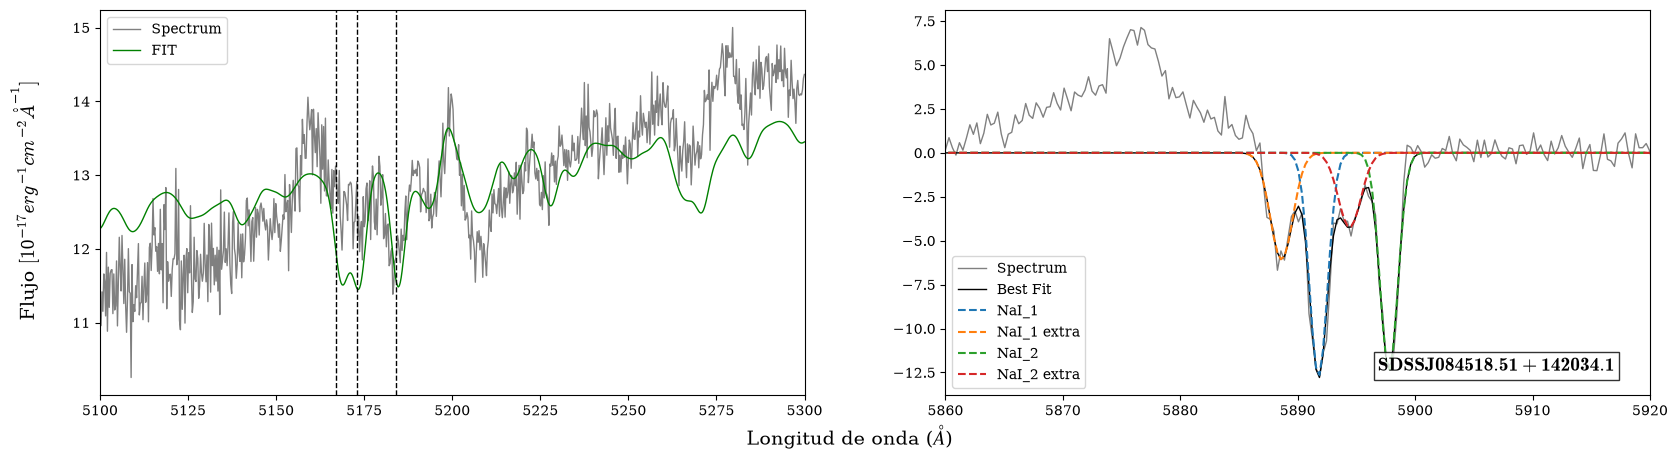

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

# --- 1. Usar el emulador interno de LaTeX de Matplotlib ---
# BORRAMOS plt.rc('text', usetex=True) para que no busque el programa externo
plt.rcParams['text.usetex'] = False
plt.rcParams['mathtext.fontset'] = 'cm'  # Fuente idéntica a la de LaTeX
plt.rcParams['font.family'] = 'serif'

fig = plt.figure(figsize=(20, 5))
gs = gridspec.GridSpec(1, 2, hspace=0.01)
componente = ['NaI_1', 'NaI_1 extra','NaI_2', 'NaI_2 extra']

# --- Gráfico de la Izquierda (Magnesio) ---
ax0 = fig.add_subplot(gs[0])
ax0.plot(wavelength_mg, f_cut_mg, 'gray', linewidth=1, label='Spectrum')
ax0.plot(wavelength_mg, fit_cut_mg, 'green', linewidth=1, label='FIT')
ax0.axvline(MgI_1, color='black', linestyle='--', linewidth=1)
ax0.axvline(MgI_2, color='black', linestyle='--', linewidth=1)
ax0.axvline(MgI_3, color='black', linestyle='--', linewidth=1)
ax0.set_xlim(5100, 5300)
ax0.legend()
ax0.tick_params(labelbottom=True)

# --- Gráfico de la Derecha (Sodio) ---
ax1 = fig.add_subplot(gs[1])
ax1.plot(wavelength_na, flux_na, 'gray', linewidth=1, label='Spectrum')
ax1.plot(wavelength_na, model_na, 'black', linewidth=1, label='Best Fit')
for i, comp in enumerate(components):
     ax1.plot(wavelength_na, comp, '--', label=componente[i])
ax1.set_xlim(5860, 5920)
# --- 2. Poner el texto usando sintaxis matemática ---
ax1.text(0.95, 0.05, r'$\mathbf{SDSS J084518.51+142034.1}$', fontsize=14, transform=ax1.transAxes,
         ha='right', va='bottom', bbox={'facecolor': 'white', 'alpha': 0.8, 'pad': 3})

ax1.legend()
ax1.tick_params(labelbottom=True)

fig.supxlabel(r'Longitud de onda ($\AA$)', fontsize=14, y = 0)
fig.supylabel('Flujo $[10^{-17} erg^{-1} cm^{-2} \mathring{A}^{-1}]$', fontsize=14, x =0.08)
plt.tight_layout()
#plt.savefig('Plots/BASS_432.png', dpi = 600)
plt.show()

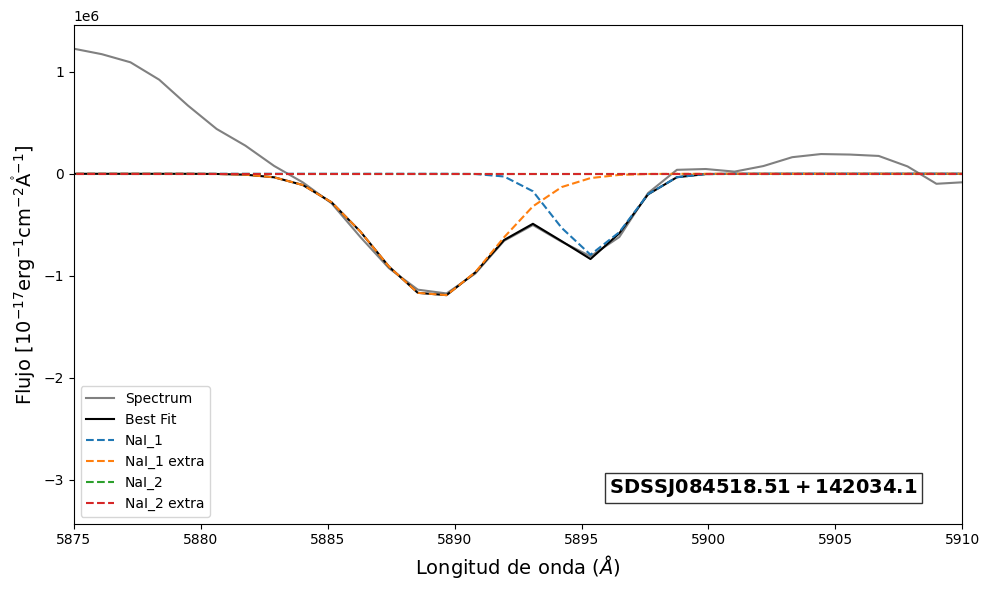

In [ ]:
import matplotlib.pyplot as plt

# Crear la figura y el único eje (ax0) al mismo tiempo
fig, ax0 = plt.subplots(figsize=(10, 6))

componente = ['NaI_1', 'NaI_1 extra','NaI_2', 'NaI_2 extra']

# Graficar espectro, modelo y componentes
ax0.plot(wavelength_na, flux_na, 'gray', label='Spectrum')
ax0.plot(wavelength_na, model_na, 'black', label='Best Fit')
for i, comp in enumerate(components):
    ax0.plot(wavelength_na, comp, '--', label=componente[i])

# Configuraciones del gráfico
ax0.set_xlim(5875, 5910)
ax0.legend()

# Etiquetas de los ejes
ax0.set_xlabel(r'Longitud de onda ($\AA$)', fontsize=14)
ax0.set_ylabel(r'Flujo $[10^{-17} \mathrm{erg}^{-1} \mathrm{cm}^{-2} \mathring{\mathrm{A}}^{-1}]$', fontsize=14)

# Corrección: Cambiamos ax1.transAxes por ax0.transAxes
ax0.text(0.95, 0.05, r'$\mathbf{SDSS J084518.51+142034.1}$', fontsize=14, transform=ax0.transAxes,
         ha='right', va='bottom', bbox={'facecolor': 'white', 'alpha': 0.8, 'pad': 3})

# Se eliminaron las líneas de ax1.legend() y ax1.tick_params()
# ya que la leyenda se llamó arriba y los ticks ya son visibles por defecto en un solo gráfico.

plt.tight_layout()
#plt.savefig('Plots/solo_432.png', dpi=600)
plt.show()

In [ ]:
eqw = spec.specfit.EQW()
print(f"Equivalent Width: {eqw}")

# To plot a box representing the EQW
eqw_plotted = spec.specfit.EQW(plot=True)

Equivalent Width: 4.326367896466082


In [ ]:
eqw_mg = spec_mg.specfit.EQW()
print(f"Equivalent Width: {eqw_mg}")

# To plot a box representing the EQW
eqw_plotted_mg = spec_mg.specfit.EQW(plot=True)

Equivalent Width: 1.3385179216803933


In [ ]:
lambda_NaI_narrow1 = ((abs(params[1] - 5890.0))/5890)*c
lambda_NaI_broad1 = ((abs(params[4] - 5890.0))/5890)*c
lambda_NaI_narrow2 = ((abs(params[7] - 5896.0))/5896)*c
lambda_NaI_broad2 = ((abs(params[10] - 5896.0))/5896)*c

In [ ]:
sigma_broad1 = (params[5]/5890)*c
sigma_broad2 = (params[11]/5896)*c

delta_lambda = (lambda_NaI_narrow1 - lambda_NaI_broad1)
Vout = (abs(delta_lambda) + 2*sigma_broad1)

delta_lambda_2 = (lambda_NaI_narrow2 - lambda_NaI_broad2)
Vout_2 = (abs(delta_lambda) + 2*sigma_broad2)

print(delta_lambda)
print(delta_lambda_2)
print(sigma_broad1)
print(sigma_broad2)
print(Vout)
print(Vout_2)

46.49885130749221
46.45153225935026
96.10566764433737
96.00786676138861
238.71018659616695
238.51458483026943
